# 모델 해석과 파인튜닝 실무 전략

## 학습 목표

1. **Grad-CAM으로 CNN 모델의 판단 근거 시각화**: 딥러닝 모델이 이미지의 어느 영역을 보고 판단했는지 히트맵으로 확인하는 방법을 학습함
2. **TensorBoard와 Callbacks로 학습 과정 추적**: 모델 학습의 진행 상황을 실시간으로 모니터링하고, 과적합 방지 및 최적 모델 저장 기법을 익힘
3. **joblib과 Pipeline으로 모델 저장 및 관리**: 학습된 모델과 전처리 과정을 통합하여 저장하고 재사용하는 실무 기법을 습득함
4. **전이학습과 파인튜닝으로 사전학습 모델 활용**: 적은 데이터로도 높은 성능을 달성할 수 있는 전이학습 전략을 이해하고 적용함

## 실습 데이터셋 소개: 주조 제품 불량 검출 데이터

본 강의에서는 **Kaggle의 Casting Product Image Dataset**을 활용함. 이 데이터셋은 실제 제조 현장에서 수집된 주조(Casting) 제품의 이미지로 구성되어 있음.

### 데이터셋 특성

| 항목 | 내용 |
|------|------|
| 출처 | Kaggle - Real-life Industrial Dataset of Casting Product |
| 총 이미지 수 | 7,348장 |
| 이미지 크기 | 300 x 300 픽셀 (흑백) |
| 클래스 | 2개 (정상: ok_front, 불량: def_front) |
| 제품 유형 | 수중 펌프 임펠러(Submersible Pump Impeller) |

### 주조(Casting) 공정 이해

주조는 용융된 금속을 원하는 형태의 주형(Mold)에 부어 응고시키는 제조 공정임. 이 과정에서 다양한 결함이 발생할 수 있음:

- **기공(Porosity)**: 가스 포집으로 인한 구멍
- **수축(Shrinkage)**: 응고 시 체적 감소로 인한 함몰
- **균열(Crack)**: 냉각 과정의 응력으로 인한 갈라짐
- **표면 결함**: 주형 표면 불량으로 인한 거칠기

In [1]:
# 필요 라이브러리 설치 (Colab 환경)
# !pip install tensorflow matplotlib numpy opencv-python scikit-learn joblib

In [2]:
# 기본 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
try:
    # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    try:
        # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    except:
        # Linux/Colab
        !apt-get install -y fonts-nanum > /dev/null 2>&1
        plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2

# OpenCV
import cv2

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 기타
import os
import datetime
import json
from pathlib import Path

print(f"TensorFlow 버전: {tf.__version__}")
print(f"GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 버전: 2.20.0
GPU 사용 가능: False


# 1: 딥러닝 모델 해석 - Grad-CAM

## 1.1 블랙박스 문제의 이해

딥러닝 모델은 뛰어난 성능을 보이지만, 내부 동작 원리를 인간이 직관적으로 이해하기 어렵다는 근본적인 문제가 있음. 이를 **블랙박스(Black Box) 문제**라고 함.

```mermaid
flowchart LR
    A[입력 이미지] --> B[CNN 모델]
    B --> C[Conv 층들]
    C --> D[Fully Connected]
    D --> E[출력: 불량]
    
    style B fill:#f9f,stroke:#333
    style C fill:#bbf,stroke:#333
    
    subgraph BlackBox[블랙박스 영역]
        B
        C
        D
    end
```

### 블랙박스 문제의 핵심 이슈

| 문제 | 설명 |
|------|------|
| 해석 불가 | 수백만 개의 파라미터가 복잡하게 상호작용하여 결과를 도출함 |
| 신뢰 부족 | "왜 이런 예측을 했는가?"라는 질문에 답변이 불가함 |
| 디버깅 어려움 | 모델이 잘못된 특징을 학습했는지 확인이 어려움 |
| 규제 대응 | 금융, 의료 분야에서는 의사결정 근거 설명이 법적 의무임 |

## 1.2 설명 가능한 AI (XAI)의 필요성

**XAI(eXplainable Artificial Intelligence)**: 인공지능의 판단 과정을 인간이 이해할 수 있도록 설명하는 기술 분야임.

### 제조업에서 XAI가 필요한 이유

| 상황 | XAI 적용 효과 |
|------|-------------|
| 불량 검출 | 어떤 영역의 결함 때문에 불량 판정했는지 작업자가 확인 가능 |
| 오탐(False Positive) 분석 | 정상 제품을 불량으로 판정한 원인 규명 |
| 미탐(False Negative) 분석 | 불량 제품을 정상으로 판정한 원인 규명 |
| 모델 개선 | 모델이 잘못 학습한 특징 발견 및 수정 |
| 품질 개선 | AI가 집중하는 결함 영역을 통해 공정 개선 포인트 발견 |

### XAI의 세 가지 목적

1. **신뢰 구축(Trust Building)**: 모델의 판단 근거를 이해해야 현장에서 AI 시스템을 신뢰하고 활용할 수 있음

2. **디버깅(Debugging)**: 모델이 배경이나 무관한 특징을 보고 판단하는지 확인하여 오류 수정 가능

3. **지식 발견(Knowledge Discovery)**: 모델이 중요하게 여기는 특성을 통해 새로운 도메인 지식 획득 가능

## 1.3 Grad-CAM의 수학적 원리

**Grad-CAM(Gradient-weighted Class Activation Map)** 은 CNN의 마지막 합성곱 층에서 특정 클래스에 대한 기울기를 가중치로 사용하여 히트맵을 생성하는 기법임.

### Grad-CAM 알고리즘 단계

```mermaid
flowchart TD
    A[1. 순전파: 이미지를 모델에 통과] --> B[2. 마지막 Conv 층의 Feature Map 획득]
    B --> C[3. 타겟 클래스에 대한 기울기 계산]
    C --> D[4. Global Average Pooling으로 가중치 계산]
    D --> E[5. Feature Map의 가중 합산]
    E --> F[6. ReLU 적용 및 정규화]
    F --> G[7. 원본 이미지 크기로 업샘플링]
```

### 수학적 정의

#### Step 1: 기울기 계산

타겟 클래스 $c$의 출력 스코어 $y^c$에 대한 마지막 합성곱 층의 $k$번째 feature map $A^k$의 기울기를 계산함:

$$\frac{\partial y^c}{\partial A^k_{ij}}$$

여기서 $i, j$는 feature map의 공간적 위치(높이, 너비)를 나타냄.

#### Step 2: 가중치(중요도) 계산 - Global Average Pooling

기울기를 공간 방향으로 평균하여 각 feature map $k$의 중요도 $\alpha_k^c$를 계산함:

$$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}$$

여기서 $Z$는 feature map의 총 픽셀 수 ($Z = H' \times W'$)임.

**직관적 의미**: $\alpha_k^c$는 클래스 $c$를 예측할 때 $k$번째 feature map이 얼마나 중요한지를 나타냄.

#### Step 3: 가중 합산 및 ReLU

각 feature map을 해당 가중치로 곱하고 합산한 뒤, ReLU를 적용함:

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c \cdot A^k\right)$$

**ReLU를 적용하는 이유**: 클래스 $c$에 긍정적인 영향을 미치는 영역만 시각화하기 위함. 음수 값은 다른 클래스에 기여하는 영역을 의미함.

### 수식 전개 예시

3개의 feature map이 있고, 각각 $2 \times 2$ 크기라고 가정함.

**Feature Maps:**

$$A^1 = \begin{bmatrix} 0.5 & 0.2 \\ 0.3 & 0.1 \end{bmatrix}, \quad
A^2 = \begin{bmatrix} 0.8 & 0.1 \\ 0.4 & 0.2 \end{bmatrix}, \quad
A^3 = \begin{bmatrix} 0.1 & 0.6 \\ 0.2 & 0.3 \end{bmatrix}$$

**기울기 (예시):**

$$\frac{\partial y^c}{\partial A^1} = \begin{bmatrix} 0.4 & 0.2 \\ 0.3 & 0.1 \end{bmatrix}, \quad
\frac{\partial y^c}{\partial A^2} = \begin{bmatrix} 0.1 & 0.1 \\ 0.1 & 0.1 \end{bmatrix}, \quad
\frac{\partial y^c}{\partial A^3} = \begin{bmatrix} -0.2 & 0.1 \\ 0.0 & -0.1 \end{bmatrix}$$

**가중치 계산:**

$$\alpha_1^c = \frac{1}{4}(0.4 + 0.2 + 0.3 + 0.1) = 0.25$$

$$\alpha_2^c = \frac{1}{4}(0.1 + 0.1 + 0.1 + 0.1) = 0.10$$

$$\alpha_3^c = \frac{1}{4}(-0.2 + 0.1 + 0.0 - 0.1) = -0.05$$

**가중 합산:**

$$L^c = 0.25 \cdot A^1 + 0.10 \cdot A^2 + (-0.05) \cdot A^3$$

$$= 0.25 \begin{bmatrix} 0.5 & 0.2 \\ 0.3 & 0.1 \end{bmatrix} + 0.10 \begin{bmatrix} 0.8 & 0.1 \\ 0.4 & 0.2 \end{bmatrix} - 0.05 \begin{bmatrix} 0.1 & 0.6 \\ 0.2 & 0.3 \end{bmatrix}$$

$$= \begin{bmatrix} 0.125 & 0.050 \\ 0.075 & 0.025 \end{bmatrix} + \begin{bmatrix} 0.080 & 0.010 \\ 0.040 & 0.020 \end{bmatrix} - \begin{bmatrix} 0.005 & 0.030 \\ 0.010 & 0.015 \end{bmatrix}$$

$$= \begin{bmatrix} 0.200 & 0.030 \\ 0.105 & 0.030 \end{bmatrix}$$

**ReLU 적용**: 모든 값이 양수이므로 결과 동일.

**해석**: 좌상단(0.200)이 가장 높은 활성화를 보여, 해당 영역이 클래스 $c$ 예측에 가장 중요함을 의미함.

## ML 해석 기법 vs DL 해석 기법

### ML 모델 해석 기법

| 기법 | 설명 | 적용 대상 | 특징 |
|:----:|:----:|:--------:|:----:|
| Feature Importance | 변수별 중요도 순위 | 트리 기반 모델 | 트리 분할 기여도 계산 |
| SHAP Values | 각 변수의 예측 기여도 | 모든 모델 | 게임 이론 기반, 정확한 기여도 |
| Permutation Importance | 변수 셔플 후 성능 변화 | 모든 모델 | 모델 비의존적 |
| Partial Dependence Plot | 변수와 예측의 관계 | 모든 모델 | 변수의 한계 효과 시각화 |

### DL 특화 해석 기법 (본 차시)

| 기법 | 설명 | 적용 대상 | 특징 |
|:----:|:----:|:--------:|:----:|
| Saliency Map | 입력 픽셀별 기울기 | 모든 DNN | 픽셀 수준의 중요도 |
| Grad-CAM | 활성화 맵 기반 히트맵 | CNN | 영역 단위의 중요도 |
| Attention 시각화 | 어텐션 가중치 분석 | Transformer | 토큰 간 관계 시각화 |
| Activation Maximization | 뉴런 활성화 최대화 입력 | CNN | 뉴런이 학습한 패턴 시각화 |

**핵심 차이**: ML은 **"변수별"** 중요도를 분석하고, DL은 **"입력 영역별"** 기여도를 분석함.

## 1.4 Grad-CAM 구현

In [17]:
def make_gradcam_heatmap(model, image, last_conv_layer_name, pred_index=None):
    """
    Grad-CAM 히트맵을 생성하는 함수 (Keras 3.x 호환)
    """
    # 마지막 Conv 층 가져오기
    last_conv_layer = model.get_layer(last_conv_layer_name)
    
    # 마지막 Conv 층까지의 모델 생성
    last_conv_model = tf.keras.Model(model.inputs, last_conv_layer.output)
    
    # 마지막 Conv 층 이후의 분류기 부분 구성
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    
    # last_conv_layer 이후의 층들을 순차적으로 적용
    found = False
    for layer in model.layers:
        if found:
            x = layer(x)
        if layer.name == last_conv_layer_name:
            found = True
    
    classifier_model = tf.keras.Model(classifier_input, x)
    
    with tf.GradientTape() as tape:
        # Conv 층 출력 계산
        conv_outputs = last_conv_model(image)
        tape.watch(conv_outputs)
        
        # 분류기 출력 계산
        predictions = classifier_model(conv_outputs)
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        
        class_channel = predictions[:, pred_index]
    
    # 기울기 계산
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

In [18]:
def apply_gradcam_overlay(original_image, heatmap, alpha=0.4):
    """
    Grad-CAM 히트맵을 원본 이미지에 오버레이하는 함수
    
    히트맵을 컬러맵으로 변환한 후 원본 이미지와 합성하여
    모델이 주목한 영역을 직관적으로 확인할 수 있게 함.
    
    Parameters
    ----------
    original_image : np.ndarray
        원본 이미지, shape: (H, W, C) 또는 (H, W), 값 범위 0-255
    heatmap : np.ndarray
        Grad-CAM 히트맵, shape: (H', W'), 값 범위 0-1
    alpha : float
        오버레이 투명도 (0: 원본만, 1: 히트맵만)
    
    Returns
    -------
    superimposed : np.ndarray
        오버레이된 이미지, shape: (H, W, 3)
    """
    # 원본 이미지가 흑백인 경우 3채널로 변환
    if len(original_image.shape) == 2:
        original_image = cv2.cvtColor(original_image, cv2.COLOR_GRAY2RGB)
    elif original_image.shape[2] == 1:
        original_image = cv2.cvtColor(original_image, cv2.COLOR_GRAY2RGB)
    
    # 히트맵을 원본 이미지 크기로 리사이즈
    heatmap_resized = cv2.resize(
        heatmap,
        (original_image.shape[1], original_image.shape[0])
    )
    
    # 0-255 범위로 스케일링
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    
    # JET 컬러맵 적용
    # 파랑(낮은 값) -> 초록 -> 노랑 -> 빨강(높은 값)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # 원본 이미지와 오버레이
    original_float = original_image.astype(np.float32)
    heatmap_float = heatmap_colored.astype(np.float32)
    superimposed = heatmap_float * alpha + original_float * (1 - alpha)
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    
    return superimposed

## 1.5 주조 불량 검출 CNN 모델 구축

Grad-CAM을 적용하기 위한 간단한 CNN 모델을 구축함. 실제로는 **사전학습 모델** 을 사용하는 것이 일반적이나, 구조 이해를 위해 직접 설계함.

In [19]:
def build_casting_cnn(input_shape=(300, 300, 1), num_classes=2):
    """
    주조 제품 불량 검출을 위한 CNN 모델 구축
    
    구조:
    - 3개의 Convolutional Block (Conv -> BatchNorm -> ReLU -> MaxPool)
    - Flatten -> Dense -> Dropout -> Output
    
    Parameters
    ----------
    input_shape : tuple
        입력 이미지 형태
    num_classes : int
        출력 클래스 수
    
    Returns
    -------
    model : tf.keras.Model
        컴파일된 CNN 모델
    """
    model = models.Sequential([
        # 입력 층
        layers.Input(shape=input_shape),
        
        # Block 1: 32 필터
        layers.Conv2D(32, (3, 3), padding='same', name='conv1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2: 64 필터
        layers.Conv2D(64, (3, 3), padding='same', name='conv2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3: 128 필터 (Grad-CAM 대상 층)
        layers.Conv2D(128, (3, 3), padding='same', name='conv3_gradcam'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # 분류기
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# 모델 생성 및 구조 확인
cnn_model = build_casting_cnn()
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 300, 300, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 300, 300, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 300, 300, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 150, 150, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 150, 150, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 150, 150, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 150, 150, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_gradcam (Conv2D)               │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 75, 75, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 75, 75, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 175232)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │      44,859,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,953,730 (171.48 MB)

 Trainable params: 44,953,282 (171.48 MB)

 Non-trainable params: 448 (1.75 KB)

## 1.6 시뮬레이션 데이터로 Grad-CAM 시연

실제 주조 데이터 대신, 학습 원리 이해를 위한 시뮬레이션 이미지로 Grad-CAM을 시연함.

> **참고**: 실제 Kaggle 데이터셋은 https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product 에서 다운로드 가능함.

학습 데이터: (160, 128, 128, 1)
테스트 데이터: (40, 128, 128, 1)


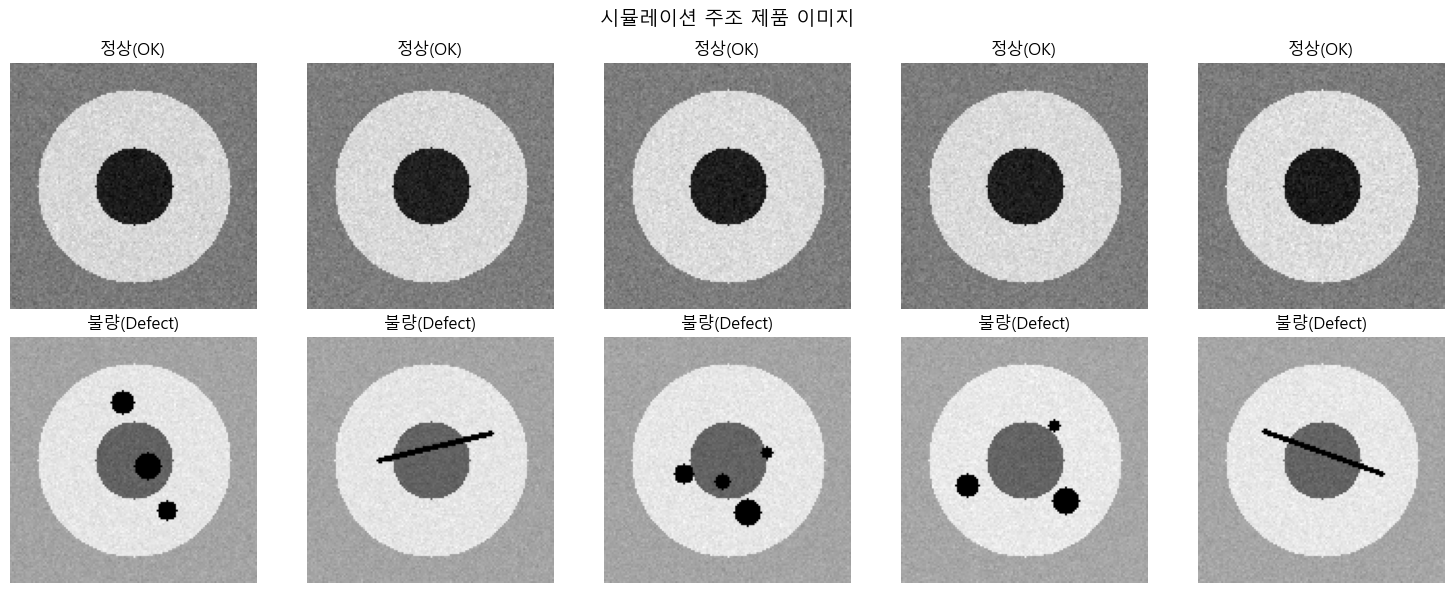

In [20]:
def create_synthetic_casting_images(n_samples=100):
    """
    주조 불량 검출 학습용 시뮬레이션 이미지 생성
    
    - 정상(OK): 균일한 원형 패턴
    - 불량(Defect): 결함(어두운 점, 균열) 포함
    """
    images = []
    labels = []
    
    for i in range(n_samples):
        # 기본 이미지: 회색 배경
        img = np.ones((128, 128), dtype=np.float32) * 0.7
        
        # 중앙에 원형 제품 형태 추가
        cv2.circle(img, (64, 64), 50, 0.9, -1)
        cv2.circle(img, (64, 64), 20, 0.5, -1)  # 내부 구멍
        
        # 노이즈 추가
        noise = np.random.normal(0, 0.02, img.shape)
        img = np.clip(img + noise, 0, 1)
        
        if i < n_samples // 2:
            # 정상 제품
            labels.append([1, 0])  # [OK, Defect]
        else:
            # 불량 제품: 결함 추가
            defect_type = np.random.randint(0, 3)
            
            if defect_type == 0:
                # 기공 (어두운 점)
                for _ in range(np.random.randint(2, 5)):
                    dx = np.random.randint(-30, 30)
                    dy = np.random.randint(-30, 30)
                    cv2.circle(img, (64 + dx, 64 + dy), np.random.randint(3, 8), 0.2, -1)
            elif defect_type == 1:
                # 균열 (선)
                start = (np.random.randint(30, 50), np.random.randint(40, 80))
                end = (np.random.randint(78, 98), np.random.randint(40, 80))
                cv2.line(img, start, end, 0.2, 2)
            else:
                # 표면 결함 (불균일 영역)
                cx, cy = np.random.randint(40, 90), np.random.randint(40, 90)
                cv2.ellipse(img, (cx, cy), (15, 10), 0, 0, 360, 0.3, -1)
            
            labels.append([0, 1])  # [OK, Defect]
        
        images.append(img)
    
    X = np.array(images)[..., np.newaxis]  # (N, 128, 128, 1)
    y = np.array(labels)
    
    return X, y

# 데이터 생성
X_sim, y_sim = create_synthetic_casting_images(200)
X_train, X_test, y_train, y_test = train_test_split(X_sim, y_sim, test_size=0.2, random_state=42)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

# 샘플 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # 정상 샘플
    idx_ok = np.where(y_sim[:, 0] == 1)[0][i]
    axes[0, i].imshow(X_sim[idx_ok, :, :, 0], cmap='gray')
    axes[0, i].set_title('정상(OK)')
    axes[0, i].axis('off')
    
    # 불량 샘플
    idx_def = np.where(y_sim[:, 1] == 1)[0][i]
    axes[1, i].imshow(X_sim[idx_def, :, :, 0], cmap='gray')
    axes[1, i].set_title('불량(Defect)')
    axes[1, i].axis('off')

plt.suptitle('시뮬레이션 주조 제품 이미지', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# 모델 학습
cnn_model_sim = build_casting_cnn(input_shape=(128, 128, 1))

history = cnn_model_sim.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# 성능 평가
test_loss, test_acc = cnn_model_sim.evaluate(X_test, y_test, verbose=0)
print(f"\n테스트 정확도: {test_acc:.2%}")

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.5875 - loss: 13.8649 - val_accuracy: 0.4750 - val_loss: 1.6863
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.8750 - loss: 1.2569 - val_accuracy: 0.4750 - val_loss: 3.4957
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.9438 - loss: 0.5546 - val_accuracy: 0.5250 - val_loss: 2.1808
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.9563 - loss: 0.3273 - val_accuracy: 0.5250 - val_loss: 12.9112
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9688 - loss: 0.2007 - val_accuracy: 0.5250 - val_loss: 15.1789
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.9500 - loss: 0.1907 - val_accuracy: 0.5250 - val_loss: 20.0210
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.9875 - loss: 0.0439 - val_accuracy: 0.5250 - val_loss: 20.0222
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.9937 - loss: 0.0340 - val_accurac

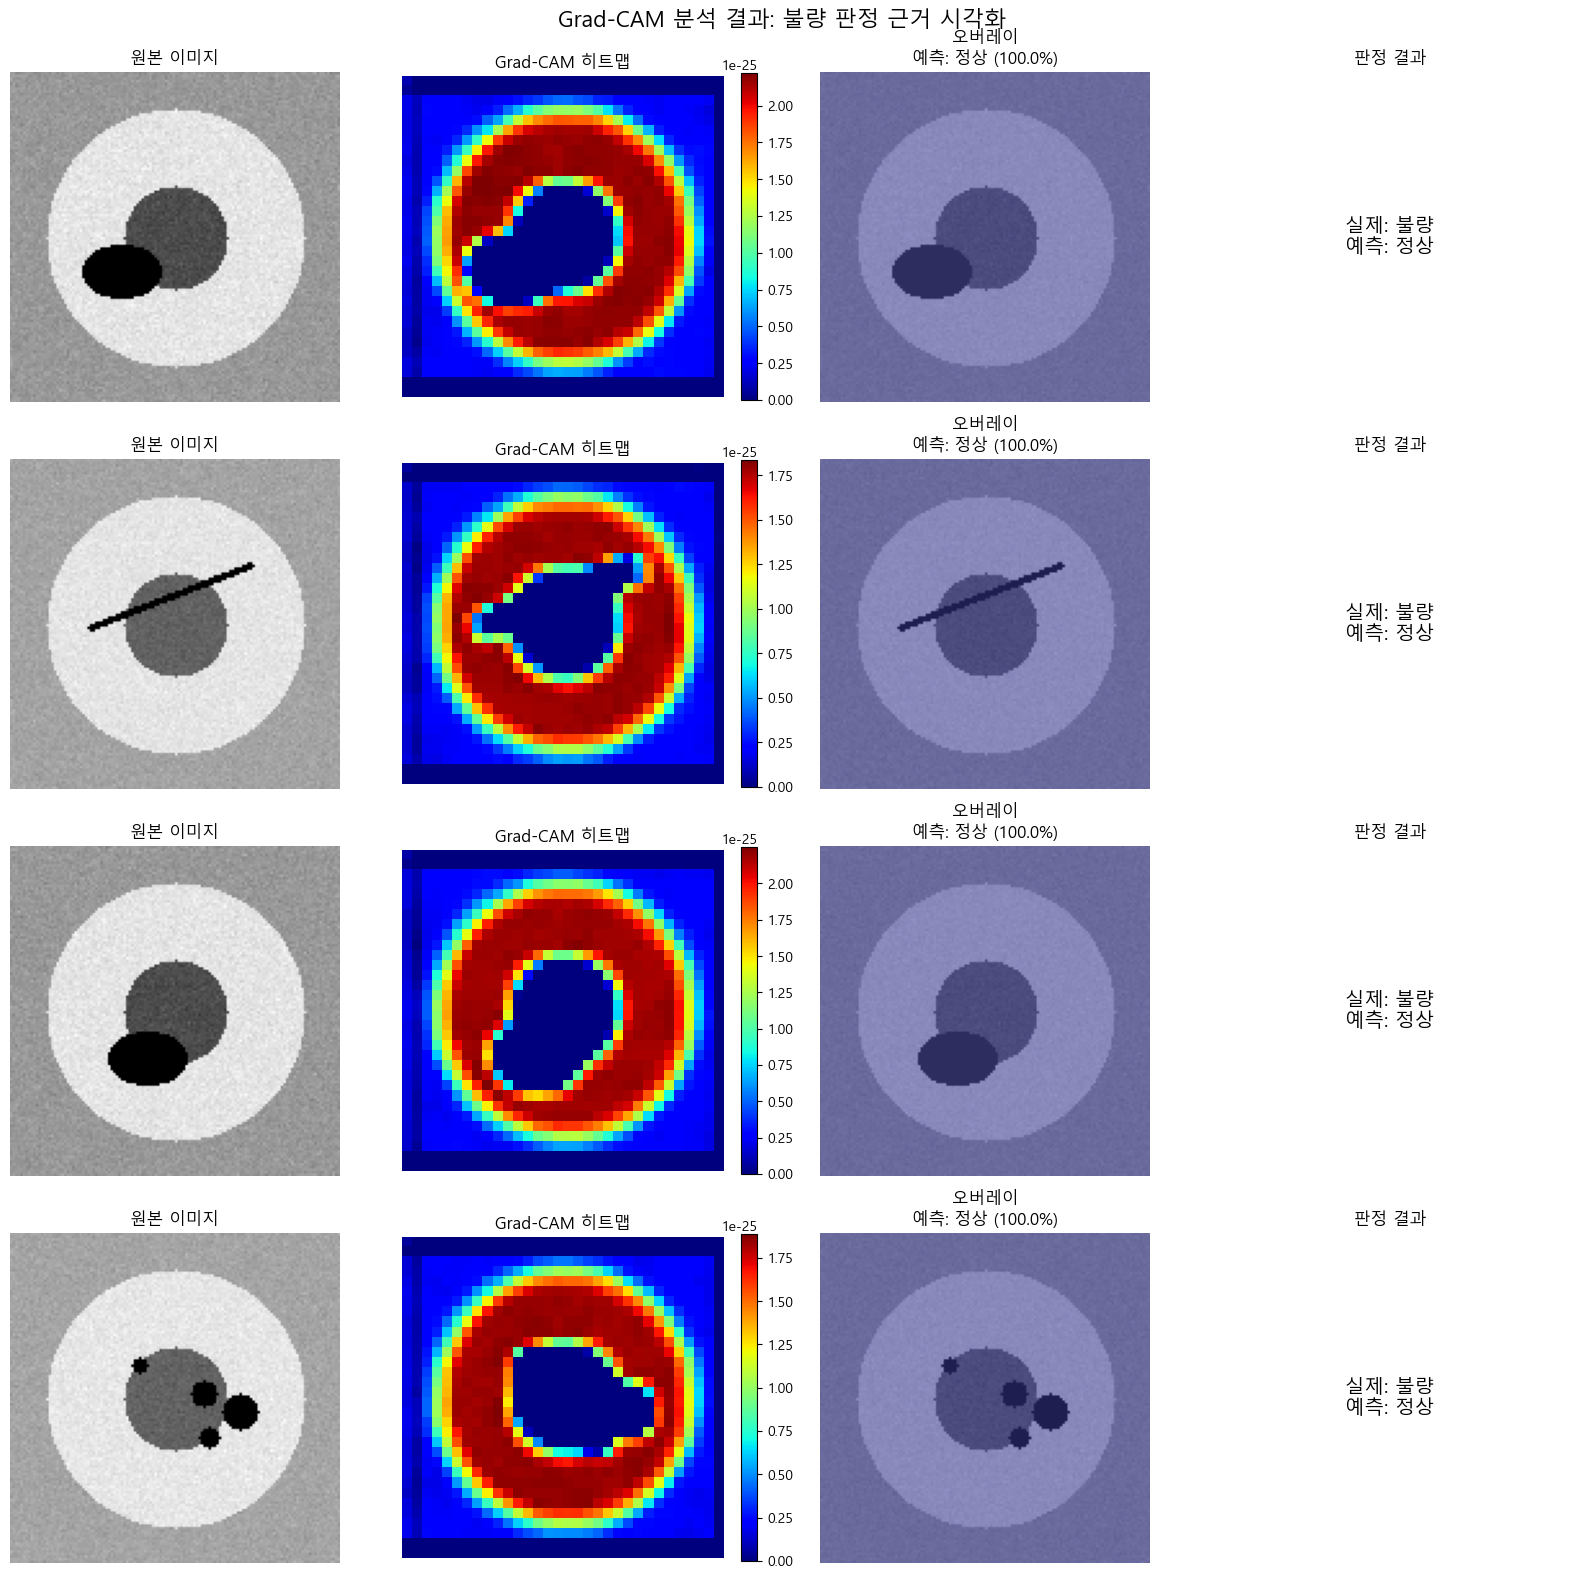

In [22]:
def visualize_gradcam_results(model, test_images, test_labels, 
                              last_conv_layer='conv3_gradcam',
                              class_names=['정상', '불량'],
                              n_samples=4):
    """
    여러 샘플에 대해 Grad-CAM 결과를 시각화하는 함수
    """
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    # 불량 샘플 선택
    defect_indices = np.where(test_labels[:, 1] == 1)[0][:n_samples]
    
    for i, idx in enumerate(defect_indices):
        img = test_images[idx]
        img_batch = img[np.newaxis, ...]  # 배치 차원 추가
        
        # 예측
        pred = model.predict(img_batch, verbose=0)
        pred_class = np.argmax(pred[0])
        pred_prob = pred[0][pred_class]
        
        # Grad-CAM 생성
        heatmap = make_gradcam_heatmap(model, img_batch, last_conv_layer, pred_class)
        
        # 오버레이 생성
        img_uint8 = (img[:, :, 0] * 255).astype(np.uint8)
        overlay = apply_gradcam_overlay(img_uint8, heatmap, alpha=0.4)
        
        # 시각화
        # 원본 이미지
        axes[i, 0].imshow(img[:, :, 0], cmap='gray')
        axes[i, 0].set_title('원본 이미지')
        axes[i, 0].axis('off')
        
        # Grad-CAM 히트맵
        im = axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title('Grad-CAM 히트맵')
        axes[i, 1].axis('off')
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046)
        
        # 오버레이
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f'오버레이\n예측: {class_names[pred_class]} ({pred_prob:.1%})')
        axes[i, 2].axis('off')
        
        # 실제 레이블
        true_class = np.argmax(test_labels[idx])
        axes[i, 3].text(0.5, 0.5, f'실제: {class_names[true_class]}\n예측: {class_names[pred_class]}',
                        ha='center', va='center', fontsize=14,
                        transform=axes[i, 3].transAxes)
        axes[i, 3].set_title('판정 결과')
        axes[i, 3].axis('off')
    
    plt.suptitle('Grad-CAM 분석 결과: 불량 판정 근거 시각화', fontsize=16)
    plt.tight_layout()
    plt.show()

# Grad-CAM 시각화 실행
visualize_gradcam_results(cnn_model_sim, X_test, y_test)

### Grad-CAM 결과 해석

위 시각화 결과에서 확인할 수 있는 사항:

1. **히트맵의 빨간색 영역**: 모델이 불량 판정에 가장 중요하게 고려한 영역
2. **결함 위치와의 일치**: 실제 결함(기공, 균열, 표면 결함)이 있는 위치와 히트맵의 활성화 영역이 일치하는지 확인
3. **모델 신뢰성 검증**: 결함이 없는 영역에 높은 활성화가 있다면 모델이 잘못된 특징을 학습했을 가능성이 있음

**제조 현장 활용**:
- 품질 관리자가 AI 판정 결과를 검증할 때 활용
- 오탐(False Positive) 원인 분석
- 새로운 유형의 결함 패턴 발견

---

# 2. 학습 추적 - TensorBoard와 Callbacks

---

## 2.1 학습 모니터링의 중요성

딥러닝 모델 학습은 시간이 오래 걸리고 많은 자원을 소모함. 따라서 학습 과정을 실시간으로 모니터링하여 문제를 조기에 발견하고 대응하는 것이 중요함.

### 모니터링해야 할 핵심 지표

| 지표 | 정상 패턴 | 이상 패턴 |
|------|----------|----------|
| Loss 곡선 | 점진적 감소 후 수렴 | 발산, 진동, 정체 |
| Train vs Val 차이 | 유사하게 감소 | Train만 감소 (과적합) |
| 정확도 | 점진적 증가 | 초기부터 높음 (데이터 누수) |
| 기울기 분포 | 안정적 범위 유지 | 소실 또는 폭발 |

```mermaid
flowchart TD
    A[학습 시작] --> B{Loss 감소?}
    B -->|Yes| C{Val Loss도 감소?}
    B -->|No| D[학습률 조정 필요]
    C -->|Yes| E[정상 학습 진행]
    C -->|No| F[과적합 발생]
    F --> G[Early Stopping 또는 정규화]
    E --> H{수렴?}
    H -->|Yes| I[학습 완료]
    H -->|No| E
```

## 2.2 Keras Callbacks 개념

**Callback**: 학습 과정의 특정 시점에 자동으로 실행되는 함수 집합임.

### Callback 실행 시점

```
on_train_begin()           ← 학습 시작
│
├── on_epoch_begin()       ← 각 에포크 시작
│   │
│   ├── on_batch_begin()   ← 각 배치 시작
│   │   └── [학습 수행]
│   └── on_batch_end()     ← 각 배치 종료
│   
└── on_epoch_end()         ← 각 에포크 종료
    └── [검증 수행]

on_train_end()             ← 학습 종료
```

### 주요 내장 Callbacks

| Callback | 기능 |
|----------|------|
| `TensorBoard` | 학습 과정 시각화 로그 저장 |
| `EarlyStopping` | 성능 개선이 없으면 조기 종료 |
| `ModelCheckpoint` | 최적 모델 자동 저장 |
| `ReduceLROnPlateau` | 성능 정체 시 학습률 감소 |
| `CSVLogger` | 학습 로그를 CSV로 저장 |

## 2.3 TensorBoard 설정 및 활용

In [23]:
# TensorBoard 로그 디렉토리 설정
# 타임스탬프를 포함하여 여러 실험을 구분할 수 있게 함
log_dir = os.path.join(
    "logs", "fit",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)
os.makedirs(log_dir, exist_ok=True)

# TensorBoard Callback 생성
tensorboard_callback = TensorBoard(
    log_dir=log_dir,            # 로그 저장 경로
    histogram_freq=1,           # 매 에포크마다 가중치 히스토그램 기록
    write_graph=True,           # 모델 그래프 저장 (구조 시각화)
    write_images=True,          # 가중치를 이미지로 저장
    update_freq='epoch',        # 업데이트 주기
    profile_batch=(10, 15)      # 배치 10~15에서 프로파일링
)

print(f"TensorBoard 로그 디렉토리: {log_dir}")
print("\nTensorBoard 실행 방법:")
print(f"1. 터미널: tensorboard --logdir={log_dir}")
print("2. 브라우저: http://localhost:6006")

TensorBoard 로그 디렉토리: logs\fit\20260119-014615

TensorBoard 실행 방법:
1. 터미널: tensorboard --logdir=logs\fit\20260119-014615
2. 브라우저: http://localhost:6006


In [30]:
# Jupyter Notebook에서 TensorBoard 인라인 실행 (선택사항)
# Colab이나 Jupyter Lab에서 사용 가능

%load_ext tensorboard
%tensorboard --logdir logs/fit

## 2.4 EarlyStopping - 과적합 방지

**과적합(Overfitting)**: 모델이 학습 데이터에 지나치게 적합하여 새로운 데이터에 대한 일반화 성능이 저하되는 현상.

### EarlyStopping 동작 원리

지정된 에포크(`patience`) 동안 검증 성능이 개선되지 않으면 학습을 조기 종료함.

```
Epoch 1:  val_loss = 0.5000  (Best)
Epoch 2:  val_loss = 0.4500  (개선, Best 갱신)
Epoch 3:  val_loss = 0.4200  (개선, Best 갱신)
Epoch 4:  val_loss = 0.4180  (개선, Best 갱신)
Epoch 5:  val_loss = 0.4200  (악화, patience=1)
Epoch 6:  val_loss = 0.4300  (악화, patience=2)
...
Epoch 14: val_loss = 0.4800  (악화, patience=10)
→ 학습 종료, Epoch 4의 가중치로 복원
```

In [25]:
# EarlyStopping Callback 설정
early_stopping = EarlyStopping(
    monitor='val_loss',         # 모니터링할 지표
    patience=10,                # 개선 없이 기다릴 에포크 수
    min_delta=0.001,            # 개선으로 인정할 최소 변화량
    mode='min',                 # 'min': 감소가 개선, 'max': 증가가 개선
    restore_best_weights=True,  # 최적 가중치로 복원
    verbose=1                   # 종료 시 메시지 출력
)

print("EarlyStopping 설정 완료")
print(f"- 모니터링 지표: {early_stopping.monitor}")
print(f"- 인내심(patience): {early_stopping.patience} 에포크")
print(f"- 최소 개선량: {early_stopping.min_delta}")

EarlyStopping 설정 완료
- 모니터링 지표: val_loss
- 인내심(patience): 10 에포크
- 최소 개선량: 0.001


## 2.5 ModelCheckpoint - 최적 모델 저장

학습 과정에서 검증 성능이 가장 좋은 시점의 모델을 자동으로 저장함.

In [26]:
# 모델 저장 디렉토리
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ModelCheckpoint - 최적 모델만 저장
checkpoint_best = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'best_casting_model.keras'),
    monitor='val_accuracy',     # 모니터링 지표
    save_best_only=True,        # 최고 성능일 때만 저장
    save_weights_only=False,    # 전체 모델 저장 (구조 + 가중치)
    mode='max',                 # 정확도는 높을수록 좋음
    verbose=1
)

# ModelCheckpoint - 에포크별 저장 (선택사항)
checkpoint_epoch = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'model_epoch_{epoch:02d}_acc_{val_accuracy:.4f}.keras'),
    save_freq='epoch',          # 매 에포크마다
    save_best_only=False        # 모든 에포크 저장
)

print(f"모델 저장 경로: {MODEL_DIR}")

모델 저장 경로: ./models


## 2.6 ReduceLROnPlateau - 학습률 자동 감소

학습 초기에는 큰 학습률로 빠르게 수렴하고, 성능이 정체되면 학습률을 낮춰 세밀하게 조정함.

### 수학적 배경

경사 하강법에서 파라미터 업데이트:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla L(\theta_t)$$

여기서 $\eta$가 학습률임. 학습률이 너무 크면 최적점을 지나치고, 너무 작으면 수렴이 느림.

```
Loss
  │
  │    큰 학습률: 발산 가능
  │   ╱
  │  ╱
  │ ╱      적절한 학습률: 수렴
  │╱     ╱
  ├────╱─────────── 최적점
  │   ╱         작은 학습률: 느린 수렴
  └───────────────────→ 반복 횟수
```

In [27]:
# ReduceLROnPlateau Callback 설정
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',         # 모니터링 지표
    factor=0.5,                 # 학습률 감소 비율 (새 LR = 기존 LR × 0.5)
    patience=5,                 # 5 에포크 동안 개선 없으면 감소
    min_lr=1e-6,                # 최소 학습률 (이 이하로는 감소하지 않음)
    min_delta=0.001,            # 개선 기준
    verbose=1
)

print("ReduceLROnPlateau 설정 완료")
print(f"- 감소 비율: {reduce_lr.factor} (LR × 0.5)")
print(f"- 최소 학습률: {reduce_lr.min_lr}")

ReduceLROnPlateau 설정 완료
- 감소 비율: 0.5 (LR × 0.5)
- 최소 학습률: 1e-06


## 2.7 복합 Callback 적용 실습

In [28]:
# 모든 Callback 통합
callbacks_list = [
    tensorboard_callback,
    early_stopping,
    checkpoint_best,
    reduce_lr
]

# 새 모델 생성
model_with_callbacks = build_casting_cnn(input_shape=(128, 128, 1))

# 학습 실행
print("\n=== Callbacks를 적용한 모델 학습 ===")
print(f"TensorBoard 로그: {log_dir}")
print(f"모델 저장 경로: {MODEL_DIR}/best_casting_model.keras")
print("="*50)

history_callbacks = model_with_callbacks.fit(
    X_train, y_train,
    epochs=50,  # 최대 에포크 (EarlyStopping으로 조기 종료 가능)
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=callbacks_list,
    verbose=1
)

print("\n=== 학습 완료 ===")
print(f"실제 학습 에포크: {len(history_callbacks.history['loss'])}")


=== Callbacks를 적용한 모델 학습 ===
TensorBoard 로그: logs\fit\20260119-014615
모델 저장 경로: ./models/best_casting_model.keras
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5982 - loss: 20.4482
Epoch 1: val_accuracy improved from None to 0.47500, saving model to ./models\best_casting_model.keras

Epoch 1: finished saving model to ./models\best_casting_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step - accuracy: 0.5250 - loss: 17.9052 - val_accuracy: 0.4750 - val_loss: 1.1822 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6107 - loss: 5.4835
Epoch 2: val_accuracy did not improve from 0.47500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - accuracy: 0.7000 - loss: 3.2892 - val_accuracy: 0.4250 - val_loss: 0.6946 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8182 - loss: 0.6812
Epoch 3: val_accuracy improved from 0.47500 to 0.52500, saving model to ./models\best_casting_model.keras

Epoch 3: fini

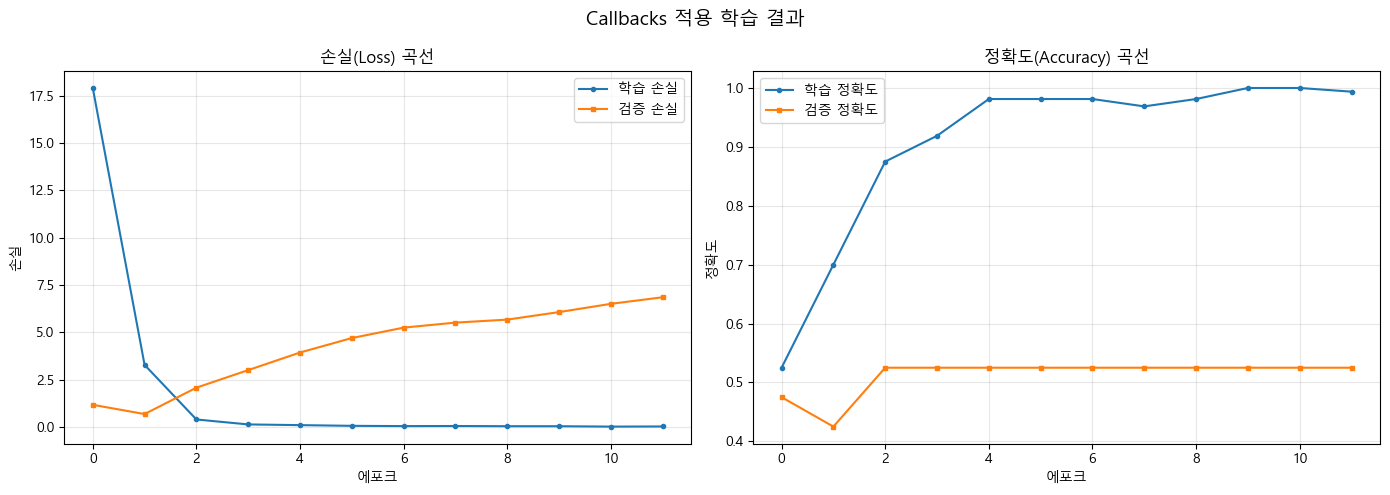


=== 학습 결과 분석 ===
최종 학습 손실: 0.0396
최종 검증 손실: 6.8590
Train-Val Gap: 6.8193
경고: 과적합 의심됨. 정규화나 데이터 증강 고려 필요.


In [29]:
# 학습 곡선 시각화
def plot_training_history(history, title='학습 곡선'):
    """
    학습 과정의 Loss와 Accuracy 곡선을 시각화하는 함수
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss 곡선
    axes[0].plot(history.history['loss'], label='학습 손실', marker='o', markersize=3)
    axes[0].plot(history.history['val_loss'], label='검증 손실', marker='s', markersize=3)
    axes[0].set_title('손실(Loss) 곡선', fontsize=12)
    axes[0].set_xlabel('에포크')
    axes[0].set_ylabel('손실')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy 곡선
    axes[1].plot(history.history['accuracy'], label='학습 정확도', marker='o', markersize=3)
    axes[1].plot(history.history['val_accuracy'], label='검증 정확도', marker='s', markersize=3)
    axes[1].set_title('정확도(Accuracy) 곡선', fontsize=12)
    axes[1].set_xlabel('에포크')
    axes[1].set_ylabel('정확도')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 과적합 여부 분석
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    gap = final_val_loss - final_train_loss
    
    print("\n=== 학습 결과 분석 ===")
    print(f"최종 학습 손실: {final_train_loss:.4f}")
    print(f"최종 검증 손실: {final_val_loss:.4f}")
    print(f"Train-Val Gap: {gap:.4f}")
    
    if gap > 0.1:
        print("경고: 과적합 의심됨. 정규화나 데이터 증강 고려 필요.")
    else:
        print("양호: 과적합 징후 없음.")

plot_training_history(history_callbacks, 'Callbacks 적용 학습 결과')

# 3. 모델 저장과 Pipeline

## 3.1 모델 저장의 필요성

딥러닝 모델 학습은 많은 시간과 컴퓨팅 자원을 소모함. 학습된 모델을 저장하면 다음과 같은 이점이 있음:

| 상황 | 저장 없이 | 저장 후 |
|------|----------|--------|
| 새 데이터 예측 | 매번 재학습 (수 시간) | 로드 후 즉시 예측 (수 초) |
| 배포 | 학습 환경 전체 필요 | 모델 파일만 배포 |
| 재현성 | 보장 어려움 | 동일 결과 재현 가능 |
| 협업 | 학습 과정 공유 필요 | 모델 파일만 공유 |

### 모델 저장 방식 비교

| 방식 | 라이브러리 | 장점 | 단점 |
|------|-----------|------|------|
| **joblib** | scikit-learn | 대용량 NumPy 배열 효율적, sklearn 권장 | Python 전용 |
| **pickle** | Python 표준 | 표준 라이브러리, 범용 | 대용량 비효율, 보안 이슈 |
| **Keras .keras** | TensorFlow | Keras 모델 전용, 구조 포함 | TensorFlow 전용 |
| **ONNX** | ONNX 런타임 | 언어 중립, 배포 최적화 | 변환 과정 필요 |

## 3.2 Keras 모델 저장 및 로드

In [31]:
# Keras 모델 저장 (.keras 형식 권장)
keras_model_path = os.path.join(MODEL_DIR, 'casting_cnn_full.keras')
model_with_callbacks.save(keras_model_path)
print(f"Keras 모델 저장 완료: {keras_model_path}")

# 파일 크기 확인
model_size_mb = os.path.getsize(keras_model_path) / (1024 * 1024)
print(f"모델 파일 크기: {model_size_mb:.2f} MB")

# 모델 로드
loaded_keras_model = tf.keras.models.load_model(keras_model_path)
print("\n모델 로드 완료")

# 검증
original_acc = model_with_callbacks.evaluate(X_test, y_test, verbose=0)[1]
loaded_acc = loaded_keras_model.evaluate(X_test, y_test, verbose=0)[1]

print(f"원본 모델 정확도: {original_acc:.4f}")
print(f"로드 모델 정확도: {loaded_acc:.4f}")
print(f"일치 여부: {np.isclose(original_acc, loaded_acc)}")

Keras 모델 저장 완료: ./models\casting_cnn_full.keras
모델 파일 크기: 97.14 MB

모델 로드 완료
원본 모델 정확도: 0.4250
로드 모델 정확도: 0.4250
일치 여부: True


## 3.3 scikit-learn Pipeline의 필요성

머신러닝 파이프라인에서 전처리 단계를 별도로 관리하면 여러 문제가 발생할 수 있음:

```
문제 상황:

학습 시:
1. scaler = StandardScaler()
2. X_train_scaled = scaler.fit_transform(X_train)
3. model.fit(X_train_scaled, y_train)

배포 시:
1. X_new_scaled = scaler.transform(X_new)  ← scaler를 어디서?
2. prediction = model.predict(X_new_scaled)
```

**Pipeline**은 전처리와 모델을 하나의 객체로 통합하여 이 문제를 해결함.

```mermaid
flowchart LR
    A[원본 데이터] --> B[Pipeline]
    subgraph B[Pipeline]
        direction LR
        C[StandardScaler] --> D[PCA] --> E[RandomForest]
    end
    B --> F[예측 결과]
```

## 3.4 Pipeline 구성 및 활용 (제조 품질 예측 예시)

이미지 데이터 외에 수치형 센서 데이터를 활용한 품질 예측 시나리오를 구현함.

In [32]:
# 시뮬레이션: 주조 공정 센서 데이터 생성
np.random.seed(42)
n_samples = 500

# 센서 데이터 생성
sensor_data = pd.DataFrame({
    '용탕_온도': np.random.normal(700, 20, n_samples),        # 섭씨
    '주입_속도': np.random.normal(2.5, 0.5, n_samples),       # m/s
    '주형_온도': np.random.normal(250, 30, n_samples),        # 섭씨
    '냉각_시간': np.random.normal(60, 10, n_samples),         # 초
    '진공_압력': np.random.normal(-0.8, 0.1, n_samples),      # bar
    '습도': np.random.normal(45, 10, n_samples)               # %
})

# 품질 레이블 생성 (복합 조건 기반)
# 용탕 온도가 너무 낮거나 주입 속도가 너무 빠르면 불량 확률 증가
defect_prob = (
    0.3 * (sensor_data['용탕_온도'] < 680).astype(int) +
    0.3 * (sensor_data['주입_속도'] > 3.0).astype(int) +
    0.2 * (sensor_data['냉각_시간'] < 50).astype(int) +
    0.2 * (sensor_data['습도'] > 55).astype(int)
)
quality_label = (np.random.random(n_samples) < defect_prob).astype(int)

print("생성된 센서 데이터:")
print(sensor_data.head())
print(f"\n불량률: {quality_label.mean():.2%}")

생성된 센서 데이터:
        용탕_온도     주입_속도       주형_온도      냉각_시간     진공_압력         습도
0  709.934283  2.963089  291.980663  67.783611 -0.867518  50.706130
1  697.234714  3.454708  277.739010  54.488143 -0.814452  54.681847
2  712.953771  1.800716  251.788911  51.818011 -0.879242  41.686916
3  730.460597  2.781485  230.591897  59.966255 -0.830796  38.877633
4  695.316933  2.174679  270.946699  58.298154 -0.989361  34.148495

불량률: 14.80%


In [33]:
# 데이터 분할
X = sensor_data.values
y = quality_label

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {X_train_pipe.shape}")
print(f"테스트 데이터: {X_test_pipe.shape}")

학습 데이터: (400, 6)
테스트 데이터: (100, 6)


In [34]:
# Pipeline 구성
# 전처리(스케일링) + 모델(RandomForest)을 하나로 통합

quality_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # 1단계: 표준화
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))                                   # 2단계: 분류
])

# 학습 (Pipeline이 자동으로 순서대로 처리)
quality_pipeline.fit(X_train_pipe, y_train_pipe)

# 평가 (Pipeline이 자동으로 스케일링 후 예측)
train_acc_pipe = quality_pipeline.score(X_train_pipe, y_train_pipe)
test_acc_pipe = quality_pipeline.score(X_test_pipe, y_test_pipe)

print("=== Pipeline 학습 결과 ===")
print(f"학습 정확도: {train_acc_pipe:.2%}")
print(f"테스트 정확도: {test_acc_pipe:.2%}")

=== Pipeline 학습 결과 ===
학습 정확도: 100.00%
테스트 정확도: 87.00%


In [35]:
# Pipeline 저장 (전처리 + 모델 통째로)
pipeline_path = os.path.join(MODEL_DIR, 'quality_pipeline.pkl')
joblib.dump(quality_pipeline, pipeline_path)
print(f"Pipeline 저장 완료: {pipeline_path}")

# 파일 크기
pipe_size_kb = os.path.getsize(pipeline_path) / 1024
print(f"파일 크기: {pipe_size_kb:.1f} KB")

# 압축 저장 (대용량 모델의 경우 권장)
pipeline_compressed_path = os.path.join(MODEL_DIR, 'quality_pipeline_compressed.pkl.gz')
joblib.dump(quality_pipeline, pipeline_compressed_path, compress=3)
compressed_size_kb = os.path.getsize(pipeline_compressed_path) / 1024
print(f"압축 저장 완료: {pipeline_compressed_path}")
print(f"압축 후 크기: {compressed_size_kb:.1f} KB (압축률: {(1-compressed_size_kb/pipe_size_kb)*100:.1f}%)")

Pipeline 저장 완료: ./models\quality_pipeline.pkl
파일 크기: 662.0 KB
압축 저장 완료: ./models\quality_pipeline_compressed.pkl.gz
압축 후 크기: 130.0 KB (압축률: 80.4%)


In [36]:
# Pipeline 로드 및 검증
loaded_pipeline = joblib.load(pipeline_path)

# 새로운 데이터로 예측 (전처리 자동 적용)
new_sample = np.array([[
    690,    # 용탕_온도
    2.8,    # 주입_속도
    260,    # 주형_온도
    55,     # 냉각_시간
    -0.75,  # 진공_압력
    50      # 습도
]])

prediction = loaded_pipeline.predict(new_sample)
prediction_proba = loaded_pipeline.predict_proba(new_sample)

print("=== 새로운 샘플 예측 ===")
print(f"입력값: {new_sample[0]}")
print(f"예측 결과: {'불량' if prediction[0] == 1 else '정상'}")
print(f"확률: 정상 {prediction_proba[0][0]:.2%}, 불량 {prediction_proba[0][1]:.2%}")

=== 새로운 샘플 예측 ===
입력값: [690.     2.8  260.    55.    -0.75  50.  ]
예측 결과: 정상
확률: 정상 96.93%, 불량 3.07%


## 3.5 메타데이터 관리

모델과 함께 메타데이터를 저장하면 버전 관리 및 재현성 확보에 도움이 됨.

In [37]:
import sklearn

# 메타데이터 구성
metadata = {
    'model_name': 'casting_quality_predictor',
    'version': 'v1.0.0',
    'created_at': datetime.datetime.now().isoformat(),
    'sklearn_version': sklearn.__version__,
    'python_version': '3.x',
    'features': list(sensor_data.columns),
    'target': 'quality (0: 정상, 1: 불량)',
    'train_accuracy': float(train_acc_pipe),
    'test_accuracy': float(test_acc_pipe),
    'n_samples_train': len(X_train_pipe),
    'n_samples_test': len(X_test_pipe),
    'model_type': 'RandomForestClassifier',
    'preprocessing': ['StandardScaler'],
    'description': '주조 공정 센서 데이터 기반 품질 예측 모델'
}

# 모델 번들 저장 (Pipeline + 메타데이터)
model_bundle = {
    'pipeline': quality_pipeline,
    'metadata': metadata
}

bundle_path = os.path.join(MODEL_DIR, 'model_bundle.pkl')
joblib.dump(model_bundle, bundle_path)
print(f"모델 번들 저장: {bundle_path}")

# 메타데이터 JSON 별도 저장 (가독성 확보)
metadata_path = os.path.join(MODEL_DIR, 'model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"메타데이터 저장: {metadata_path}")

# 메타데이터 확인
print("\n=== 저장된 메타데이터 ===")
for key, value in metadata.items():
    print(f"  {key}: {value}")

모델 번들 저장: ./models\model_bundle.pkl
메타데이터 저장: ./models\model_metadata.json

=== 저장된 메타데이터 ===
  model_name: casting_quality_predictor
  version: v1.0.0
  created_at: 2026-01-19T01:47:59.945515
  sklearn_version: 1.8.0
  python_version: 3.x
  features: ['용탕_온도', '주입_속도', '주형_온도', '냉각_시간', '진공_압력', '습도']
  target: quality (0: 정상, 1: 불량)
  train_accuracy: 1.0
  test_accuracy: 0.87
  n_samples_train: 400
  n_samples_test: 100
  model_type: RandomForestClassifier
  preprocessing: ['StandardScaler']
  description: 주조 공정 센서 데이터 기반 품질 예측 모델


# 4. 파인튜닝과 전이학습 맛보기

## 4.1 전이학습의 개념

**전이학습(Transfer Learning)**: 대규모 데이터셋에서 학습된 모델의 지식을 새로운 문제에 재활용하는 기법.

### 전이학습의 필요성

```
기존 방식:
[내 데이터 1,000장] → [처음부터 학습] → [모델] → 낮은 성능

전이학습:
[ImageNet 1,400만장] → [사전학습 모델] 
                          ↓
[내 데이터 1,000장] → [미세조정] → [고성능 모델]
```

### 전이학습의 장점

| 장점 | 설명 |
|------|------|
| 적은 데이터 | 수백~수천 장으로도 높은 성능 달성 가능 |
| 빠른 학습 | 이미 학습된 특징 활용으로 수렴 속도 향상 |
| 안정적 초기화 | 검증된 가중치에서 시작하여 학습 안정성 확보 |
| 범용 특징 활용 | 저수준 특징(엣지, 텍스처)은 대부분의 이미지에서 유사 |

```mermaid
flowchart TB
    subgraph PreTrained["사전학습 모델 (ImageNet)"]
        A[Conv 1-2: 엣지, 색상] --> B[Conv 3-4: 텍스처, 패턴]
        B --> C[Conv 5: 부분 형태]
        C --> D[FC: 1000개 클래스]
    end
    
    subgraph FineTuned["파인튜닝 후"]
        A2[Conv 1-2: 동결] --> B2[Conv 3-4: 동결]
        B2 --> C2[Conv 5: 학습 가능]
        C2 --> D2[FC: 2개 클래스 - 정상/불량]
    end
    
    PreTrained --> |전이| FineTuned
```

## 4.2 CNN의 계층적 특징 학습

CNN은 층이 깊어질수록 더 추상적인 특징을 학습함:

| 층 깊이 | 학습하는 특징 | 범용성 |
|---------|--------------|--------|
| 초반 층 | 엣지, 색상, 그라데이션 | 매우 높음 (모든 이미지에 적용) |
| 중간 층 | 텍스처, 패턴, 모서리 | 높음 |
| 후반 층 | 부분 형태, 객체 부위 | 중간 |
| 최종 층 | 클래스 특화 특징 | 낮음 (태스크 특화) |

전이학습은 초반~중간 층의 범용적 특징을 재활용하고, 후반~최종 층만 새로 학습함.

## 4.3 사전학습 모델 활용

In [38]:
# MobileNetV2 사전학습 모델 로드
# MobileNetV2는 경량 모델로, 엣지 디바이스 배포에 적합함

base_model = MobileNetV2(
    weights='imagenet',      # ImageNet 사전학습 가중치
    include_top=False,       # 최종 분류 층 제외 (우리가 추가할 것)
    input_shape=(224, 224, 3),  # 입력 형태
    pooling='avg'            # Global Average Pooling 적용
)

# 사전학습 층 동결 (가중치 고정)
base_model.trainable = False

print(f"MobileNetV2 구조:")
print(f"  - 총 층 수: {len(base_model.layers)}")
print(f"  - 학습 가능 파라미터: {sum([tf.reduce_prod(v.shape).numpy() for v in base_model.trainable_variables]):,}")
print(f"  - 고정 파라미터: {sum([tf.reduce_prod(v.shape).numpy() for v in base_model.non_trainable_variables]):,}")

MobileNetV2 구조:
  - 총 층 수: 155
  - 학습 가능 파라미터: 0
  - 고정 파라미터: 2,257,984


In [39]:
# 새로운 분류 층 추가 (주조 불량 검출용)
def build_transfer_model(base_model, num_classes=2):
    """
    사전학습 모델 위에 새로운 분류 층을 추가하는 함수
    
    Parameters
    ----------
    base_model : tf.keras.Model
        사전학습된 기본 모델 (VGG16, ResNet50, MobileNetV2 등)
    num_classes : int
        출력 클래스 수
    
    Returns
    -------
    model : tf.keras.Model
        전이학습 모델
    """
    # 입력 층
    inputs = keras.Input(shape=(224, 224, 3))
    
    # 전처리 (MobileNetV2 전용)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    
    # 사전학습 모델 통과
    x = base_model(x, training=False)  # training=False: BatchNorm 추론 모드
    
    # 새 분류 층
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# 모델 생성
transfer_model = build_transfer_model(base_model)

# 학습 가능한 파라미터 확인
print("\n=== 전이학습 모델 구조 ===")
transfer_model.summary()


=== 전이학습 모델 구조 ===


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc2 (Dense)                          │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4.4 파인튜닝: 일부 층 학습 허용

초기 학습 후 성능이 충분하지 않으면, 사전학습 모델의 일부 층을 학습 가능하게 전환하여 미세 조정함.

In [40]:
def fine_tune_model(model, base_model, num_layers_to_unfreeze=20):
    """
    파인튜닝: 사전학습 모델의 일부 층을 학습 가능하게 전환
    
    Parameters
    ----------
    model : tf.keras.Model
        전체 모델
    base_model : tf.keras.Model
        사전학습된 기본 모델
    num_layers_to_unfreeze : int
        학습 가능하게 전환할 마지막 N개 층
    
    Returns
    -------
    model : tf.keras.Model
        파인튜닝 준비된 모델
    """
    # 기본 모델 학습 가능으로 전환
    base_model.trainable = True
    
    # 마지막 N개 층만 학습 허용, 나머지 동결
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    
    # 낮은 학습률로 재컴파일 (기존 가중치 보존)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 10배 낮은 학습률
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 학습 가능한 층 확인
    trainable_count = sum([l.trainable for l in base_model.layers])
    print(f"\n=== 파인튜닝 설정 ===")
    print(f"전체 층 수: {len(base_model.layers)}")
    print(f"학습 가능 층 수: {trainable_count}")
    print(f"동결 층 수: {len(base_model.layers) - trainable_count}")
    
    return model

# 파인튜닝 적용 (예시)
# fine_tuned_model = fine_tune_model(transfer_model, base_model, num_layers_to_unfreeze=30)

## 4.5 전이학습 전략 선택 가이드

데이터 양과 원본 데이터와의 유사도에 따라 전략을 선택해야 함:

| 상황 | 데이터 양 | 유사도 | 권장 전략 |
|------|----------|--------|----------|
| Case 1 | 적음 (< 1,000) | 높음 | 특성 추출 (전체 동결) |
| Case 2 | 적음 (< 1,000) | 낮음 | 전체 동결 + 강한 정규화 |
| Case 3 | 많음 (> 10,000) | 높음 | 파인튜닝 (상위 층 학습) |
| Case 4 | 많음 (> 10,000) | 낮음 | 전체 학습 또는 Scratch |

**제조업 적용 시 고려사항**:
- 제조 이미지는 ImageNet과 유사도가 낮은 경우가 많음 (특수 조명, 특정 각도)
- 데이터 수집이 어려운 경우가 많아 데이터 양이 적음
- **권장**: Case 1 또는 Case 2 전략 + 데이터 증강(Augmentation)

In [41]:
# 다양한 사전학습 모델 비교
pretrained_models = {
    'VGG16': {
        'params': '138M',
        'size': '528MB',
        'top1_acc': '71.3%',
        '장점': '구조 단순, 해석 용이',
        '단점': '용량 큼, 속도 느림'
    },
    'ResNet50': {
        'params': '25.6M',
        'size': '98MB',
        'top1_acc': '74.9%',
        '장점': 'Skip Connection으로 깊은 학습 안정',
        '단점': '중간 크기'
    },
    'MobileNetV2': {
        'params': '3.5M',
        'size': '14MB',
        'top1_acc': '71.3%',
        '장점': '경량, 엣지 디바이스 적합',
        '단점': '성능 다소 낮음'
    },
    'EfficientNetB0': {
        'params': '5.3M',
        'size': '29MB',
        'top1_acc': '77.1%',
        '장점': '효율성 최적화, 성능/크기 균형',
        '단점': '구조 복잡'
    }
}

# 표로 출력
print("=== 사전학습 모델 비교 ===")
print(f"{'모델':<15} {'파라미터':<10} {'크기':<10} {'Top-1 정확도':<12} {'권장 용도'}")
print("-" * 70)
for name, info in pretrained_models.items():
    print(f"{name:<15} {info['params']:<10} {info['size']:<10} {info['top1_acc']:<12} {info['장점']}")

=== 사전학습 모델 비교 ===
모델              파라미터       크기         Top-1 정확도    권장 용도
----------------------------------------------------------------------
VGG16           138M       528MB      71.3%        구조 단순, 해석 용이
ResNet50        25.6M      98MB       74.9%        Skip Connection으로 깊은 학습 안정
MobileNetV2     3.5M       14MB       71.3%        경량, 엣지 디바이스 적합
EfficientNetB0  5.3M       29MB       77.1%        효율성 최적화, 성능/크기 균형


## 모델 배포 전 확인 사항

| 영역 | 확인 항목 | 완료 |
|------|----------|------|
| **모델** | 테스트 정확도 기록 | [ ] |
| | 버전 태깅 (v1.0.0 등) | [ ] |
| | Grad-CAM으로 판단 근거 검증 | [ ] |
| | 과적합 여부 확인 | [ ] |
| **데이터** | 입력 형식 문서화 | [ ] |
| | 값 범위 검증 로직 추가 | [ ] |
| | 전처리 Pipeline 포함 | [ ] |
| **환경** | requirements.txt 생성 | [ ] |
| | 라이브러리 버전 고정 | [ ] |
| | GPU/CPU 호환성 테스트 | [ ] |
| **테스트** | 단위 테스트 작성 | [ ] |
| | 예측 시간 측정 | [ ] |
| | 엣지 케이스 테스트 | [ ] |

## 핵심 내용 요약

### 1: Grad-CAM
- CNN의 판단 근거를 히트맵으로 시각화하는 XAI 기법
- 마지막 Conv 층의 기울기를 가중치로 사용하여 클래스 활성화 맵 생성
- 수식: $L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c \cdot A^k\right)$
- 제조업 활용: 불량 판정 근거 확인, 오탐 원인 분석

### 2: TensorBoard와 Callbacks
- TensorBoard: 학습 곡선 실시간 모니터링
- EarlyStopping: 과적합 방지를 위한 조기 종료
- ModelCheckpoint: 최적 모델 자동 저장
- ReduceLROnPlateau: 성능 정체 시 학습률 자동 감소

### 3: joblib과 Pipeline
- joblib: sklearn 모델 저장/로드의 표준 방법
- Pipeline: 전처리 + 모델 통합으로 배포 간소화
- 메타데이터: 버전 관리 및 재현성 확보

### 4: 전이학습과 파인튜닝
- 전이학습: 사전학습 모델의 지식 재활용
- 특성 추출: 사전학습 층 동결, 새 분류 층만 학습
- 파인튜닝: 일부 층을 학습 가능하게 전환하여 미세 조정
- 제조업 권장: MobileNetV2 (경량), EfficientNetB0 (성능/효율 균형)

## 부록: 참고자료

아래 내용은 강의 시간이 초과될 경우 별도 학습 자료로 제공함.

### A.1 다양한 XAI 기법 비교

| 기법 | 적용 모델 | 특징 | 장점 | 단점 |
|------|----------|------|------|------|
| **Grad-CAM** | CNN | 기울기 기반 활성화 맵 | 구현 용이, 범용적 | 해상도 낮음 |
| **LIME** | 모든 모델 | 지역적 선형 근사 | 모델 불문 | 계산 비용 높음 |
| **SHAP** | 모든 모델 | Shapley 값 기반 | 이론적 기반 견고 | 계산 비용 높음 |
| **Attention Map** | Transformer | 어텐션 가중치 시각화 | 직관적 | Transformer 전용 |
| **CAM** | CNN (GAP 필수) | 가중치 기반 | 빠름 | GAP 구조 필요 |

### A.2 커스텀 Callback 작성

특정 요구사항에 맞는 커스텀 Callback을 작성할 수 있음.

In [ ]:
class CustomLoggingCallback(keras.callbacks.Callback):
    """
    학습 과정을 커스텀 형식으로 로깅하는 Callback
    """
    def __init__(self, log_file='training_log.csv'):
        super().__init__()
        self.log_file = log_file
        self.logs_list = []
    
    def on_train_begin(self, logs=None):
        print(f"학습 시작 - 로그 파일: {self.log_file}")
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        log_entry = {
            'epoch': epoch + 1,
            'timestamp': datetime.datetime.now().isoformat(),
            **logs
        }
        self.logs_list.append(log_entry)
        
        # 콘솔 출력
        print(f"\n[Epoch {epoch+1}] ", end='')
        for key, value in logs.items():
            print(f"{key}: {value:.4f} | ", end='')
    
    def on_train_end(self, logs=None):
        # CSV로 저장
        df = pd.DataFrame(self.logs_list)
        df.to_csv(self.log_file, index=False)
        print(f"\n\n학습 완료 - 로그 저장: {self.log_file}")

# 사용 예시
# custom_callback = CustomLoggingCallback('my_training.csv')
# model.fit(X, y, callbacks=[custom_callback])

### A.3 ONNX 형식으로 모델 변환 (범용 배포)

ONNX(Open Neural Network Exchange)는 다양한 딥러닝 프레임워크 간 모델 교환을 위한 표준 형식임.

In [ ]:
# ONNX 변환 (tf2onnx 패키지 필요)
# !pip install tf2onnx onnx

# import tf2onnx
# import onnx

# # Keras 모델을 ONNX로 변환
# onnx_model_path = os.path.join(MODEL_DIR, 'model.onnx')
# spec = (tf.TensorSpec((None, 128, 128, 1), tf.float32, name="input"),)
# model_proto, _ = tf2onnx.convert.from_keras(cnn_model_sim, input_signature=spec)
# onnx.save_model(model_proto, onnx_model_path)

# print(f"ONNX 모델 저장: {onnx_model_path}")

print("참고: ONNX 변환은 tf2onnx 패키지 설치 후 사용 가능")